# SQL Analytics Case Study — Online Retail
> **Muhammad Rifai | Portfolio | Analytifai**

---

## Business Problem

Sebuah retailer e-commerce berbasis di UK menjual produk gifting & home décor ke 40+ negara.  
Manajemen ingin memahami:

1. **Revenue performance** — produk dan negara mana yang paling menguntungkan?
2. **Customer behaviour** — bagaimana pola pembelian dan loyalitas pelanggan?
3. **Product trends** — produk apa yang konsisten laku vs musiman?
4. **Cohort retention** — seberapa baik perusahaan mempertahankan pelanggan?

## Dataset
- **Sumber:** Online Retail UCI — transaksi 12 bulan (Des 2010 – Des 2011)
- **Struktur:** `InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, `Country`, `Revenue`
- **Tools:** Python + SQLite (via `sqlite3`) — query SQL murni

---

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#0f0f1a',
    'axes.edgecolor':   '#3a3a5a',
    'axes.labelcolor':  '#c8b8a8',
    'xtick.color':      '#c8b8a8',
    'ytick.color':      '#c8b8a8',
    'text.color':       '#c8b8a8',
    'grid.color':       '#2a2a3a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'sans-serif',
})
GOLD  = '#d4af37'
ROSE  = '#e8a4c9'
TEAL  = '#7ec8c8'
COLORS = [GOLD, ROSE, TEAL, '#9b8dc4', '#e07b6e', '#8dc49b', '#5b8dc4']

# Koneksi database
conn = sqlite3.connect('retail.db')

def query(sql, title=None):
    """Jalankan SQL dan tampilkan hasil sebagai DataFrame."""
    df = pd.read_sql_query(sql, conn)
    if title:
        print(f'\n{title}')
        print('─' * 60)
    return df

print('Koneksi database berhasil')
query('SELECT COUNT(*) as total_rows, COUNT(DISTINCT CustomerID) as customers, COUNT(DISTINCT StockCode) as products FROM transactions')

Koneksi database berhasil


,total_rows,customers,products
0,805549,5878,4631


---
## Section 1 — Data Overview & Quality Check

In [2]:
# Q1: Gambaran umum dataset
sql_q1 = """
SELECT
    COUNT(*)                              AS total_transactions,
    COUNT(DISTINCT InvoiceNo)             AS unique_invoices,
    COUNT(DISTINCT CustomerID)            AS unique_customers,
    COUNT(DISTINCT StockCode)             AS unique_products,
    COUNT(DISTINCT Country)               AS countries,
    ROUND(MIN(CAST(Revenue AS FLOAT)), 2) AS min_revenue,
    ROUND(MAX(CAST(Revenue AS FLOAT)), 2) AS max_revenue,
    ROUND(SUM(CAST(Revenue AS FLOAT)), 2) AS total_revenue,
    ROUND(AVG(CAST(Revenue AS FLOAT)), 2) AS avg_transaction_revenue
FROM transactions
"""

df_q1 = query(sql_q1, 'Q1 — Dataset Overview')
df_q1


Q1 — Dataset Overview
────────────────────────────────────────────────────────────


,total_transactions,unique_invoices,unique_customers,unique_products,countries,min_revenue,max_revenue,total_revenue,avg_transaction_revenue
0,805549,36969,5878,4631,41,0.0,168469.6,17743429.18,22.03


In [3]:
# Q2: Distribusi transaksi per negara
sql_q2 = """
SELECT
    Country,
    COUNT(DISTINCT InvoiceNo)                AS total_orders,
    COUNT(DISTINCT CustomerID)               AS customers,
    ROUND(SUM(CAST(Revenue AS FLOAT)), 2)    AS total_revenue,
    ROUND(SUM(CAST(Revenue AS FLOAT)) * 100.0 /
          SUM(SUM(CAST(Revenue AS FLOAT))) OVER (), 2) AS revenue_pct
FROM transactions
GROUP BY Country
ORDER BY total_revenue DESC
LIMIT 10
"""

df_q2 = query(sql_q2, 'Q2 — Revenue by Country (TOP 10)')
display(df_q2)

# Insight
top_country = df_q2.iloc[0]
print(f"\nInsight: {top_country['Country']} mendominasi dengan {top_country['revenue_pct']}% total revenue")


Q2 — Revenue by Country (TOP 10)
────────────────────────────────────────────────────────────


,Country,total_orders,customers,total_revenue,revenue_pct
0,United Kingdom,33541,5350,14723147.52,82.98
1,EIRE,567,5,621631.11,3.50
2,Netherlands,228,22,554232.34,3.12
3,Germany,789,107,431262.46,2.43
4,France,614,95,355257.47,2.00
5,Australia,95,15,169968.11,0.96
6,Spain,154,41,109178.53,0.62
7,Switzerland,90,22,100365.34,0.57
8,Sweden,104,19,91549.72,0.52
9,Denmark,43,12,69862.19,0.39



Insight: United Kingdom mendominasi dengan 82.98% total revenue


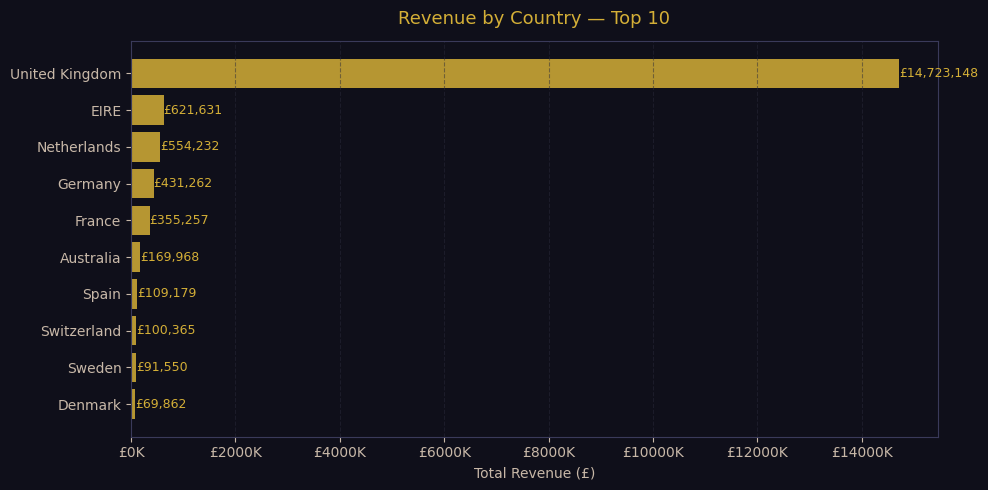

In [4]:
# Visualisasi Q2
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_q2['Country'][::-1], df_q2['total_revenue'][::-1], color=GOLD, alpha=0.85)
for bar, val in zip(bars, df_q2['total_revenue'][::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=9, color=GOLD)
ax.set_xlabel('Total Revenue (£)')
ax.set_title('Revenue by Country — Top 10', color=GOLD, fontsize=13, pad=12)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.grid(axis='x')
plt.tight_layout()
plt.savefig('chart_country_revenue.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

---
## Section 2 — Product Performance

In [5]:
# Q3: Top 10 produk by revenue
sql_q3 = """
SELECT
    StockCode,
    Description,
    COUNT(DISTINCT InvoiceNo)             AS total_orders,
    SUM(Quantity)                         AS total_qty_sold,
    ROUND(SUM(CAST(Revenue AS FLOAT)), 2) AS total_revenue,
    ROUND(AVG(CAST(UnitPrice AS FLOAT)), 2) AS avg_price
FROM transactions
GROUP BY StockCode, Description
ORDER BY total_revenue DESC
LIMIT 10
"""

df_q3 = query(sql_q3, 'Q3 — Top 10 Products by Revenue')
display(df_q3)

print("\nInsight: Produk dengan harga rendah tapi volume tinggi bisa menghasilkan revenue lebih besar")


Q3 — Top 10 Products by Revenue
────────────────────────────────────────────────────────────


,StockCode,Description,total_orders,total_qty_sold,total_revenue,avg_price
0,22423,REGENCY CAKESTAND 3 TIER,3317,24899,286486.30,12.46
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,4888,93640,252072.46,2.87
2,23843,"PAPER CRAFT , LITTLE BIRDIE",1,80995,168469.60,2.08
3,M,Manual,620,9803,152340.57,206.44
4,85099B,JUMBO BAG RED RETROSPOT,2612,75759,136980.08,1.97
5,84879,ASSORTED COLOUR BIRD ORNAMENT,2652,79913,127074.17,1.68
6,POST,POSTAGE,1803,5333,126563.04,29.75
7,47566,PARTY BUNTING,2077,23607,103880.23,4.77
8,23166,MEDIUM CERAMIC TOP STORAGE JAR,195,77916,81416.73,1.22
9,22086,PAPER CHAIN KIT 50'S CHRISTMAS,1691,29477,79594.33,2.92



Insight: Produk dengan harga rendah tapi volume tinggi bisa menghasilkan revenue lebih besar


In [6]:
# Q4: Produk dengan ranking revenue per negara (Window Function)
sql_q4 = """
WITH product_country AS (
    SELECT
        Country,
        Description,
        ROUND(SUM(CAST(Revenue AS FLOAT)), 2) AS revenue
    FROM transactions
    GROUP BY Country, Description
),
ranked AS (
    SELECT
        Country,
        Description,
        revenue,
        RANK() OVER (PARTITION BY Country ORDER BY revenue DESC) AS rank_in_country
    FROM product_country
)
SELECT *
FROM ranked
WHERE rank_in_country = 1
  AND Country IN ('United Kingdom','Germany','France','Australia','Netherlands')
ORDER BY revenue DESC
"""

df_q4 = query(sql_q4, 'Q4 — #1 Best-Selling Product per Country (Window Function: RANK)')
display(df_q4)

print("\nInsight: Produk top berbeda di tiap negara — perlu strategi assortment yang terlokalisasi")


Q4 — #1 Best-Selling Product per Country (Window Function: RANK)
────────────────────────────────────────────────────────────


,Country,Description,revenue,rank_in_country
0,United Kingdom,REGENCY CAKESTAND 3 TIER,234185.80,1
1,Germany,POSTAGE,39231.20,1
2,France,POSTAGE,25030.00,1
3,Netherlands,ROUND SNACK BOXES SET OF4 WOODLAND,13315.10,1
4,Australia,RABBIT NIGHT LIGHT,3375.84,1



Insight: Produk top berbeda di tiap negara — perlu strategi assortment yang terlokalisasi


In [7]:
# Q5: Produk dengan penjualan konsisten (hadir di banyak bulan)
sql_q5 = """
WITH monthly_product AS (
    SELECT
        StockCode,
        Description,
        SUBSTR(InvoiceDate, 1, 7) AS month,
        SUM(CAST(Revenue AS FLOAT)) AS monthly_revenue
    FROM transactions
    GROUP BY StockCode, Description, month
)
SELECT
    StockCode,
    Description,
    COUNT(DISTINCT month)                          AS active_months,
    ROUND(SUM(monthly_revenue), 2)                 AS total_revenue,
    ROUND(AVG(monthly_revenue), 2)                 AS avg_monthly_revenue,
    ROUND(MIN(monthly_revenue), 2)                 AS min_monthly_revenue,
    ROUND(MAX(monthly_revenue), 2)                 AS max_monthly_revenue
FROM monthly_product
GROUP BY StockCode, Description
HAVING active_months >= 8
ORDER BY avg_monthly_revenue DESC
LIMIT 10
"""

df_q5 = query(sql_q5, 'Q5 — Evergreen Products (Konsisten Laku ≥8 Bulan)')
display(df_q5)

print("\nInsight: Produk evergreen adalah tulang punggung inventory — prioritaskan stock availability-nya")


Q5 — Evergreen Products (Konsisten Laku ≥8 Bulan)
────────────────────────────────────────────────────────────


,StockCode,Description,active_months,total_revenue,avg_monthly_revenue,min_monthly_revenue,max_monthly_revenue
0,22423,REGENCY CAKESTAND 3 TIER,22,286486.30,13022.10,4545.03,26092.80
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,25,252072.46,10082.90,1995.79,17064.73
2,23166,MEDIUM CERAMIC TOP STORAGE JAR,9,81416.73,9046.30,203.51,77183.60
3,85099B,JUMBO BAG RED RETROSPOT,20,136980.08,6849.00,2020.40,12007.05
4,23084,RABBIT NIGHT LIGHT,8,51346.20,6418.27,235.14,23268.73
5,M,Manual,25,152340.57,6093.62,94.40,27308.20
6,84879,ASSORTED COLOUR BIRD ORNAMENT,25,127074.17,5082.97,1999.46,14345.75
7,POST,POSTAGE,25,126563.04,5062.52,2690.00,13358.75
8,23298,SPOTTY BUNTING,8,35539.25,4442.41,613.80,7187.55
9,47566,PARTY BUNTING,25,103880.23,4155.21,13.95,13437.95



Insight: Produk evergreen adalah tulang punggung inventory — prioritaskan stock availability-nya


---
## Section 3 — Customer Behaviour

In [8]:
# Q6: Customer Lifetime Value — top spender
sql_q6 = """
SELECT
    CustomerID,
    Country,
    COUNT(DISTINCT InvoiceNo)              AS total_orders,
    SUM(Quantity)                          AS total_items,
    ROUND(SUM(CAST(Revenue AS FLOAT)), 2)  AS total_revenue,
    ROUND(AVG(CAST(Revenue AS FLOAT)), 2)  AS avg_basket_value,
    ROUND(SUM(CAST(Revenue AS FLOAT)) /
          COUNT(DISTINCT InvoiceNo), 2)    AS revenue_per_order
FROM transactions
GROUP BY CustomerID, Country
ORDER BY total_revenue DESC
LIMIT 10
"""

df_q6 = query(sql_q6, 'Q6 — Top 10 Customers by Lifetime Value')
display(df_q6)

print("\nInsight: Top 10 customer berkontribusi signifikan — kandidat VIP program & personalized retention")


Q6 — Top 10 Customers by Lifetime Value
────────────────────────────────────────────────────────────


,CustomerID,Country,total_orders,total_items,total_revenue,avg_basket_value,revenue_per_order
0,18102,United Kingdom,145,188340,608821.65,575.45,4198.77
1,14646,Netherlands,151,367193,528602.52,137.34,3500.68
2,14156,EIRE,156,165992,313946.37,77.56,2012.48
3,14911,EIRE,398,149987,295972.63,26.32,743.65
4,17450,United Kingdom,51,84720,246973.09,582.48,4842.61
5,13694,United Kingdom,143,189205,196482.81,128.84,1374.01
6,17511,United Kingdom,60,119656,175603.55,91.89,2926.73
7,16446,United Kingdom,2,80997,168472.50,56157.50,84236.25
8,16684,United Kingdom,55,104810,147142.77,204.93,2675.32
9,12415,Australia,28,91447,144458.37,156.00,5159.23



Insight: Top 10 customer berkontribusi signifikan — kandidat VIP program & personalized retention



Q7 — Customer Purchase Frequency Segmentation
────────────────────────────────────────────────────────────


,frequency_segment,customer_count,pct_of_customers
0,1 order (One-time),1623,27.61
1,2–3 orders,1608,27.36
2,4–6 orders,1126,19.16
3,7–10 orders,645,10.97
4,10+ orders (Loyal),876,14.90


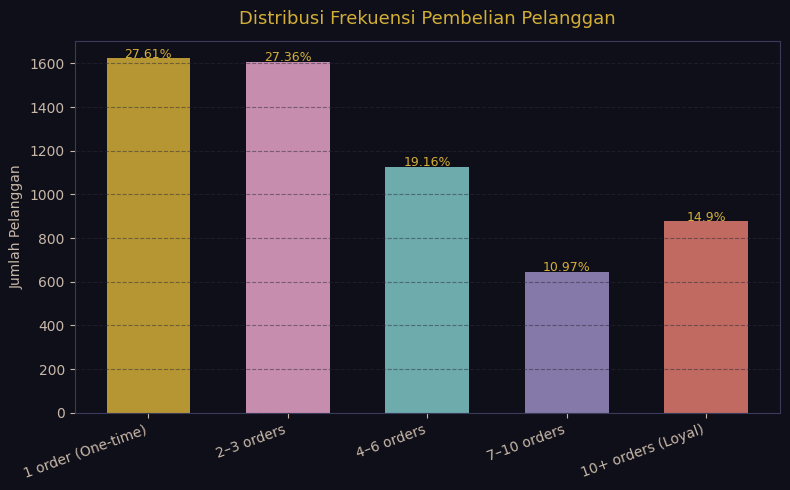


Insight: Jika mayoritas pelanggan hanya beli 1x, fokus ke strategi re-engagement campaign


In [9]:
# Q7: Distribusi frekuensi pembelian pelanggan
sql_q7 = """
WITH order_freq AS (
    SELECT
        CustomerID,
        COUNT(DISTINCT InvoiceNo) AS order_count
    FROM transactions
    GROUP BY CustomerID
)
SELECT
    CASE
        WHEN order_count = 1  THEN '1 order (One-time)'
        WHEN order_count <= 3 THEN '2–3 orders'
        WHEN order_count <= 6 THEN '4–6 orders'
        WHEN order_count <= 10 THEN '7–10 orders'
        ELSE '10+ orders (Loyal)'
    END AS frequency_segment,
    COUNT(*) AS customer_count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct_of_customers
FROM order_freq
GROUP BY frequency_segment
ORDER BY MIN(order_count)
"""

df_q7 = query(sql_q7, 'Q7 — Customer Purchase Frequency Segmentation')
display(df_q7)

# Visualisasi
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df_q7['frequency_segment'], df_q7['customer_count'],
              color=COLORS[:len(df_q7)], alpha=0.85, width=0.6)
for bar, pct in zip(bars, df_q7['pct_of_customers']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{pct}%', ha='center', fontsize=9, color=GOLD)
ax.set_ylabel('Jumlah Pelanggan')
ax.set_title('Distribusi Frekuensi Pembelian Pelanggan', color=GOLD, fontsize=13, pad=12)
ax.set_xticklabels(df_q7['frequency_segment'], rotation=20, ha='right')
ax.grid(axis='y')
plt.tight_layout()
plt.savefig('chart_frequency.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print("\nInsight: Jika mayoritas pelanggan hanya beli 1x, fokus ke strategi re-engagement campaign")

In [10]:
# Q8: Average Order Value (AOV) per negara
sql_q8 = """
SELECT
    Country,
    COUNT(DISTINCT InvoiceNo)                      AS total_orders,
    ROUND(SUM(CAST(Revenue AS FLOAT)), 2)          AS total_revenue,
    ROUND(SUM(CAST(Revenue AS FLOAT)) /
          COUNT(DISTINCT InvoiceNo), 2)            AS avg_order_value,
    ROUND(AVG(Quantity), 1)                        AS avg_items_per_order
FROM transactions
GROUP BY Country
HAVING total_orders >= 50
ORDER BY avg_order_value DESC
"""

df_q8 = query(sql_q8, 'Q8 — Average Order Value per Country')
display(df_q8)

print("\nInsight: Negara dengan AOV tinggi adalah target upselling & premium bundle strategy")


Q8 — Average Order Value per Country
────────────────────────────────────────────────────────────


,Country,total_orders,total_revenue,avg_order_value,avg_items_per_order
0,Netherlands,228,554232.34,2430.84,75.5
1,Australia,95,169968.11,1789.14,57.4
2,Switzerland,90,100365.34,1115.17,17.4
3,EIRE,567,621631.11,1096.35,20.4
4,Sweden,104,91549.72,880.29,67.1
5,Channel Islands,55,44996.76,818.12,13.7
6,Spain,154,109178.53,708.95,13.7
7,Portugal,93,57285.30,615.97,11.5
8,France,614,355257.47,578.60,19.8
9,Germany,789,431262.46,546.59,13.7



Insight: Negara dengan AOV tinggi adalah target upselling & premium bundle strategy


---
## Section 4 — Time-Based Analysis


Q9 — Monthly Revenue Trend
────────────────────────────────────────────────────────────


,month,total_orders,active_customers,total_revenue,avg_transaction_value
0,2009-12,1512,955,686654.16,22.33
1,2010-01,1011,720,557319.06,25.59
2,2010-02,1104,772,506371.07,21.67
3,2010-03,1524,1057,699608.99,21.66
4,2010-04,1329,942,594609.19,21.83
5,2010-05,1377,966,599985.79,20.95
6,2010-06,1497,1041,639066.58,20.49
7,2010-07,1381,928,591636.74,21.89
8,2010-08,1293,911,604242.65,22.89
9,2010-09,1689,1145,831615.00,24.04


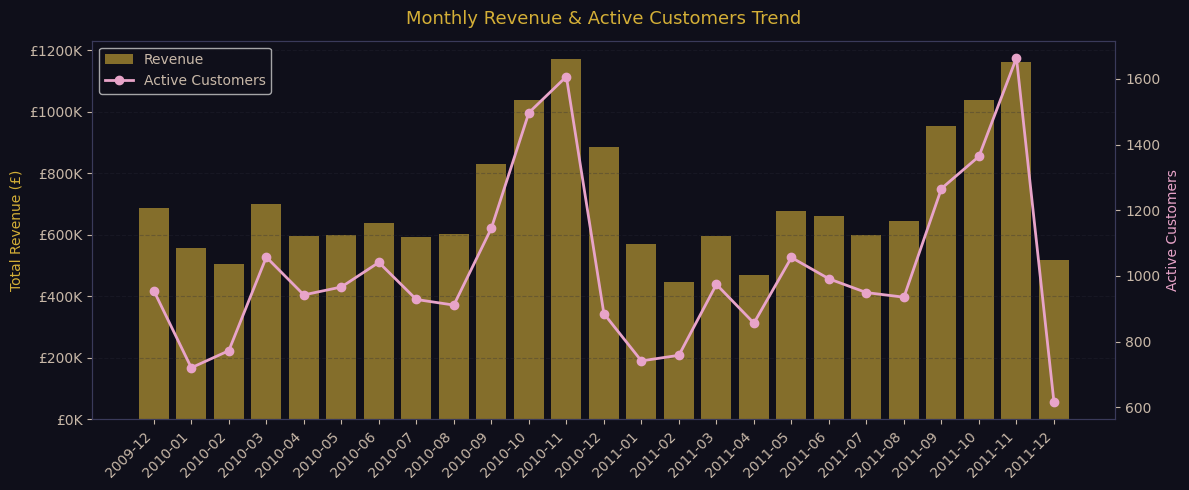


Insight: Identifikasi peak season untuk optimasi stok & marketing budget


In [11]:
# Q9: Revenue trend per bulan
sql_q9 = """
SELECT
    SUBSTR(InvoiceDate, 1, 7)              AS month,
    COUNT(DISTINCT InvoiceNo)              AS total_orders,
    COUNT(DISTINCT CustomerID)             AS active_customers,
    ROUND(SUM(CAST(Revenue AS FLOAT)), 2)  AS total_revenue,
    ROUND(AVG(CAST(Revenue AS FLOAT)), 2)  AS avg_transaction_value
FROM transactions
GROUP BY month
ORDER BY month
"""

df_q9 = query(sql_q9, 'Q9 — Monthly Revenue Trend')
display(df_q9)

# Visualisasi
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(df_q9['month'], df_q9['total_revenue'], color=GOLD, alpha=0.6, label='Revenue')
ax2 = ax1.twinx()
ax2.plot(df_q9['month'], df_q9['active_customers'], color=ROSE, marker='o', linewidth=2, label='Active Customers')
ax1.set_ylabel('Total Revenue (£)', color=GOLD)
ax2.set_ylabel('Active Customers', color=ROSE)
ax1.set_title('Monthly Revenue & Active Customers Trend', color=GOLD, fontsize=13, pad=12)
ax1.set_xticklabels(df_q9['month'], rotation=45, ha='right')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart_monthly_trend.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print("\nInsight: Identifikasi peak season untuk optimasi stok & marketing budget")

In [12]:
# Q10: Revenue MoM Growth (Month-over-Month) dengan LAG Window Function
sql_q10 = """
WITH monthly AS (
    SELECT
        SUBSTR(InvoiceDate, 1, 7)              AS month,
        ROUND(SUM(CAST(Revenue AS FLOAT)), 2)  AS revenue
    FROM transactions
    GROUP BY month
),
with_lag AS (
    SELECT
        month,
        revenue,
        LAG(revenue) OVER (ORDER BY month)     AS prev_month_revenue
    FROM monthly
)
SELECT
    month,
    revenue,
    prev_month_revenue,
    ROUND((revenue - prev_month_revenue) * 100.0 / prev_month_revenue, 2) AS mom_growth_pct
FROM with_lag
ORDER BY month
"""

df_q10 = query(sql_q10, 'Q10 — Month-over-Month Revenue Growth (LAG Window Function)')
display(df_q10)

print("\nInsight: MoM growth negatif di bulan tertentu perlu diinvestigasi — promosi atau stok masalah?")


Q10 — Month-over-Month Revenue Growth (LAG Window Function)
────────────────────────────────────────────────────────────


,month,revenue,prev_month_revenue,mom_growth_pct
0,2009-12,686654.16,NaN,NaN
1,2010-01,557319.06,686654.16,-18.84
2,2010-02,506371.07,557319.06,-9.14
3,2010-03,699608.99,506371.07,38.16
4,2010-04,594609.19,699608.99,-15.01
5,2010-05,599985.79,594609.19,0.90
6,2010-06,639066.58,599985.79,6.51
7,2010-07,591636.74,639066.58,-7.42
8,2010-08,604242.65,591636.74,2.13
9,2010-09,831615.00,604242.65,37.63



Insight: MoM growth negatif di bulan tertentu perlu diinvestigasi — promosi atau stok masalah?


---
## Section 5 — Advanced SQL: RFM Scoring

In [13]:
# Q11: RFM (Recency, Frequency, Monetary) Score per pelanggan
sql_q11 = """
WITH rfm_base AS (
    SELECT
        CustomerID,
        -- Recency: hari sejak transaksi terakhir (dari tanggal akhir dataset)
        CAST(
            (JULIANDAY('2011-12-10') - JULIANDAY(MAX(InvoiceDate)))
        AS INTEGER)                              AS recency_days,
        -- Frequency: jumlah order unik
        COUNT(DISTINCT InvoiceNo)                AS frequency,
        -- Monetary: total belanja
        ROUND(SUM(CAST(Revenue AS FLOAT)), 2)    AS monetary
    FROM transactions
    GROUP BY CustomerID
),
rfm_scored AS (
    SELECT
        CustomerID,
        recency_days,
        frequency,
        monetary,
        -- R Score: semakin kecil recency = semakin baik
        NTILE(5) OVER (ORDER BY recency_days DESC)  AS r_score,
        -- F Score: semakin tinggi frequency = semakin baik
        NTILE(5) OVER (ORDER BY frequency ASC)      AS f_score,
        -- M Score: semakin tinggi monetary = semakin baik
        NTILE(5) OVER (ORDER BY monetary ASC)       AS m_score
    FROM rfm_base
)
SELECT
    CustomerID,
    recency_days,
    frequency,
    monetary,
    r_score, f_score, m_score,
    (r_score + f_score + m_score) AS rfm_total,
    CASE
        WHEN (r_score + f_score + m_score) >= 13 THEN 'Champions'
        WHEN (r_score + f_score + m_score) >= 10 THEN 'Loyal Customers'
        WHEN (r_score + f_score + m_score) >= 7  THEN 'Potential Loyalists'
        WHEN (r_score + f_score + m_score) >= 4  THEN 'At Risk'
        ELSE 'Lost'
    END AS rfm_segment
FROM rfm_scored
ORDER BY rfm_total DESC
LIMIT 20
"""

df_q11 = query(sql_q11, 'Q11 — RFM Scoring (NTILE Window Function)')
display(df_q11)

print("\nInsight: Champions perlu VIP treatment; At Risk perlu win-back campaign segera")


Q11 — RFM Scoring (NTILE Window Function)
────────────────────────────────────────────────────────────


,CustomerID,recency_days,frequency,monetary,r_score,f_score,m_score,rfm_total,rfm_segment
0,13988,19,8,4757.80,5,5,5,15,Champions
1,17758,19,12,5012.53,5,5,5,15,Champions
2,17738,19,13,4183.56,5,5,5,15,Champions
3,12395,19,15,5067.27,5,5,5,15,Champions
4,14525,19,17,8240.64,5,5,5,15,Champions
5,14159,19,20,7938.01,5,5,5,15,Champions
6,16710,19,22,6349.09,5,5,5,15,Champions
7,12523,19,23,4372.15,5,5,5,15,Champions
8,15465,19,32,12655.65,5,5,5,15,Champions
9,12540,19,33,22254.49,5,5,5,15,Champions



Insight: Champions perlu VIP treatment; At Risk perlu win-back campaign segera



Q12 — RFM Segment Distribution
────────────────────────────────────────────────────────────


,rfm_segment,customer_count,pct,avg_monetary
0,Champions,1320,22.5,9884.94
1,Loyal Customers,1355,23.1,2206.53
2,Potential Loyalists,1439,24.5,846.17
3,At Risk,1315,22.4,319.58
4,Lost,449,7.6,150.53


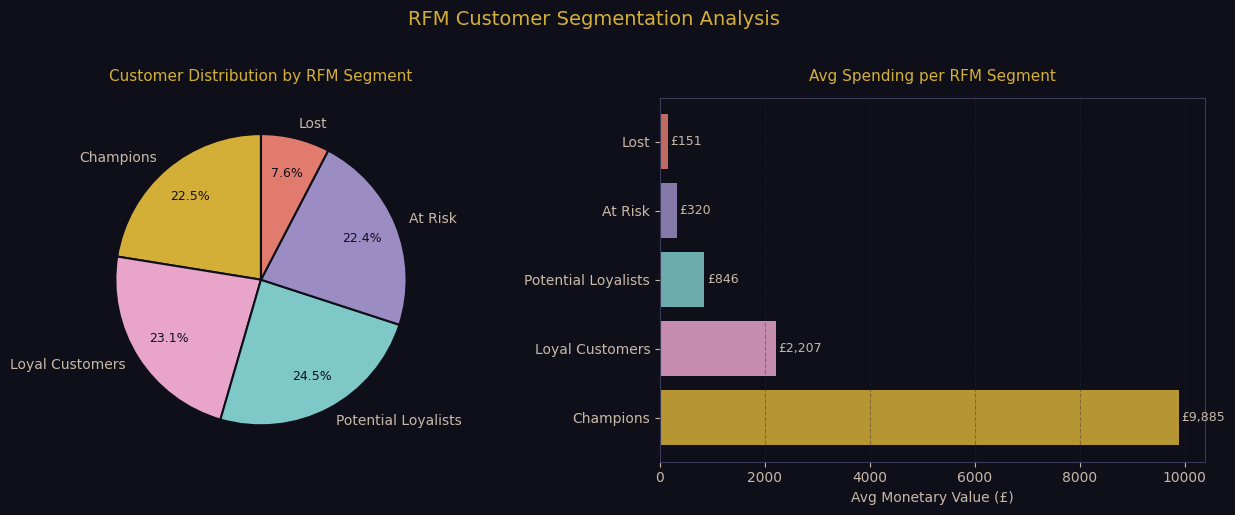


Business Recommendation:
  • Champions     → VIP program, early access produk baru
  • Loyal         → Loyalty reward, upsell bundle
  • At Risk       → Win-back email campaign, diskon personal
  • Lost          → Re-activation campaign atau stop invest


In [14]:
# Q12: Distribusi segmen RFM
sql_q12 = """
WITH rfm_base AS (
    SELECT CustomerID,
        CAST((JULIANDAY('2011-12-10') - JULIANDAY(MAX(InvoiceDate))) AS INTEGER) AS recency_days,
        COUNT(DISTINCT InvoiceNo) AS frequency,
        ROUND(SUM(CAST(Revenue AS FLOAT)), 2) AS monetary
    FROM transactions GROUP BY CustomerID
),
rfm_scored AS (
    SELECT CustomerID, monetary,
        NTILE(5) OVER (ORDER BY recency_days DESC) AS r_score,
        NTILE(5) OVER (ORDER BY frequency ASC)     AS f_score,
        NTILE(5) OVER (ORDER BY monetary ASC)      AS m_score
    FROM rfm_base
),
segmented AS (
    SELECT *,
        CASE
            WHEN (r_score+f_score+m_score) >= 13 THEN 'Champions'
            WHEN (r_score+f_score+m_score) >= 10 THEN 'Loyal Customers'
            WHEN (r_score+f_score+m_score) >= 7  THEN 'Potential Loyalists'
            WHEN (r_score+f_score+m_score) >= 4  THEN 'At Risk'
            ELSE 'Lost'
        END AS rfm_segment
    FROM rfm_scored
)
SELECT
    rfm_segment,
    COUNT(*) AS customer_count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct,
    ROUND(AVG(monetary), 2) AS avg_monetary
FROM segmented
GROUP BY rfm_segment
ORDER BY avg_monetary DESC
"""

df_q12 = query(sql_q12, 'Q12 — RFM Segment Distribution')
display(df_q12)

# Visualisasi pie
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
wedges, texts, autotexts = ax1.pie(
    df_q12['customer_count'], labels=df_q12['rfm_segment'],
    colors=COLORS[:len(df_q12)], autopct='%1.1f%%',
    pctdistance=0.75, startangle=90,
    wedgeprops=dict(edgecolor='#0f0f1a', linewidth=1.5)
)
for t in autotexts: t.set_color('#0f0f1a'); t.set_fontsize(9)
ax1.set_title('Customer Distribution by RFM Segment', color=GOLD, fontsize=11, pad=12)

bars = ax2.barh(df_q12['rfm_segment'], df_q12['avg_monetary'],
                color=COLORS[:len(df_q12)], alpha=0.85)
for bar, val in zip(bars, df_q12['avg_monetary']):
    ax2.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'£{val:,.0f}', va='center', fontsize=9)
ax2.set_xlabel('Avg Monetary Value (£)')
ax2.set_title('Avg Spending per RFM Segment', color=GOLD, fontsize=11, pad=12)
ax2.grid(axis='x', alpha=0.4)
plt.suptitle('RFM Customer Segmentation Analysis', color=GOLD, fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('chart_rfm.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print("\nBusiness Recommendation:")
print("  • Champions     → VIP program, early access produk baru")
print("  • Loyal         → Loyalty reward, upsell bundle")
print("  • At Risk       → Win-back email campaign, diskon personal")
print("  • Lost          → Re-activation campaign atau stop invest")

---
## Section 6 — Advanced SQL: Cohort & Basket Analysis

In [15]:
# Q13: Cohort — bulan pertama customer beli (acquisition cohort)
sql_q13 = """
WITH first_purchase AS (
    SELECT
        CustomerID,
        SUBSTR(MIN(InvoiceDate), 1, 7) AS cohort_month
    FROM transactions
    GROUP BY CustomerID
),
cohort_data AS (
    SELECT
        f.cohort_month,
        SUBSTR(t.InvoiceDate, 1, 7) AS order_month,
        t.CustomerID
    FROM transactions t
    JOIN first_purchase f ON t.CustomerID = f.CustomerID
)
SELECT
    cohort_month,
    COUNT(DISTINCT CustomerID)                    AS cohort_size,
    COUNT(DISTINCT CASE WHEN order_month > cohort_month THEN CustomerID END) AS returned_customers,
    ROUND(
        COUNT(DISTINCT CASE WHEN order_month > cohort_month THEN CustomerID END) * 100.0
        / COUNT(DISTINCT CustomerID), 1
    )                                             AS retention_rate_pct
FROM cohort_data
GROUP BY cohort_month
ORDER BY cohort_month
"""

df_q13 = query(sql_q13, 'Q13 — Cohort Retention Rate by Acquisition Month')
display(df_q13)

print("\nInsight: Cohort dengan retention rate tinggi menunjukkan bulan akuisisi yang lebih berkualitas")


Q13 — Cohort Retention Rate by Acquisition Month
────────────────────────────────────────────────────────────


,cohort_month,cohort_size,returned_customers,retention_rate_pct
0,2009-12,955,866,90.7
1,2010-01,383,333,86.9
2,2010-02,374,314,84.0
3,2010-03,443,359,81.0
4,2010-04,294,226,76.9
5,2010-05,254,194,76.4
6,2010-06,270,196,72.6
7,2010-07,186,134,72.0
8,2010-08,162,110,67.9
9,2010-09,243,164,67.5



Insight: Cohort dengan retention rate tinggi menunjukkan bulan akuisisi yang lebih berkualitas



Q14 — Cumulative Revenue (Running Total Window Function)
────────────────────────────────────────────────────────────


,month,monthly_revenue,cumulative_revenue,revenue_contribution_pct
0,2009-12,686654.16,686654.16,3.87
1,2010-01,557319.06,1243973.22,3.14
2,2010-02,506371.07,1750344.29,2.85
3,2010-03,699608.99,2449953.28,3.94
4,2010-04,594609.19,3044562.47,3.35
5,2010-05,599985.79,3644548.26,3.38
6,2010-06,639066.58,4283614.84,3.60
7,2010-07,591636.74,4875251.58,3.33
8,2010-08,604242.65,5479494.23,3.41
9,2010-09,831615.00,6311109.23,4.69


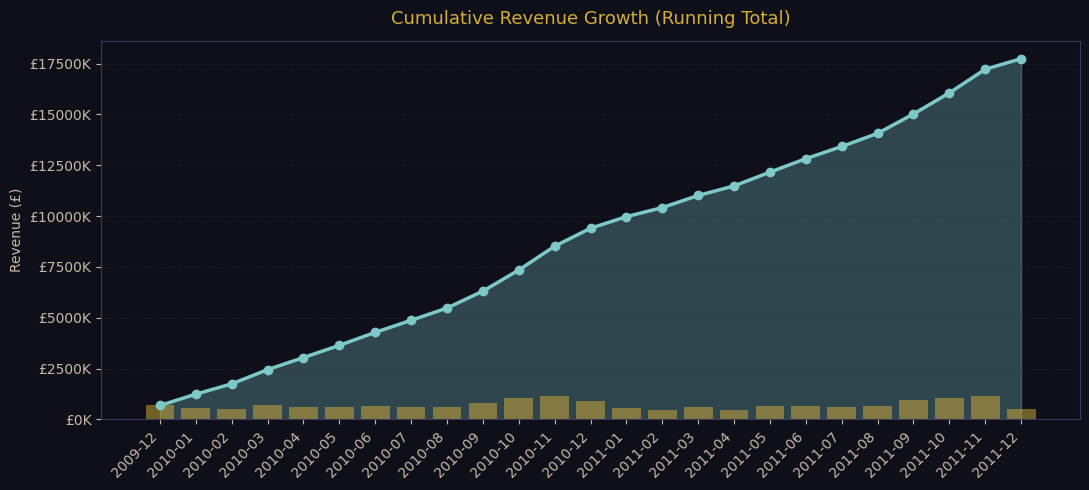

In [16]:
# Q14: Running Total Revenue (Cumulative) per bulan
sql_q14 = """
WITH monthly AS (
    SELECT
        SUBSTR(InvoiceDate, 1, 7)              AS month,
        ROUND(SUM(CAST(Revenue AS FLOAT)), 2)  AS monthly_revenue
    FROM transactions
    GROUP BY month
)
SELECT
    month,
    monthly_revenue,
    ROUND(SUM(monthly_revenue) OVER (ORDER BY month ROWS UNBOUNDED PRECEDING), 2) AS cumulative_revenue,
    ROUND(monthly_revenue * 100.0 / SUM(monthly_revenue) OVER (), 2)              AS revenue_contribution_pct
FROM monthly
ORDER BY month
"""

df_q14 = query(sql_q14, 'Q14 — Cumulative Revenue (Running Total Window Function)')
display(df_q14)

# Visualisasi
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(df_q14['month'], df_q14['cumulative_revenue'], alpha=0.3, color=TEAL)
ax.plot(df_q14['month'], df_q14['cumulative_revenue'], color=TEAL, linewidth=2.5, marker='o')
ax.bar(df_q14['month'], df_q14['monthly_revenue'], color=GOLD, alpha=0.5, label='Monthly Revenue')
ax.set_ylabel('Revenue (£)')
ax.set_title('Cumulative Revenue Growth (Running Total)', color=GOLD, fontsize=13, pad=12)
ax.set_xticklabels(df_q14['month'], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart_cumulative.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

In [17]:
# Q15: Pareto Analysis — 80/20 Rule (produk mana yang hasilkan 80% revenue)
sql_q15 = """
WITH product_rev AS (
    SELECT
        Description,
        ROUND(SUM(CAST(Revenue AS FLOAT)), 2) AS revenue
    FROM transactions
    GROUP BY Description
),
ranked AS (
    SELECT
        Description,
        revenue,
        RANK() OVER (ORDER BY revenue DESC) AS rank,
        ROUND(SUM(revenue) OVER (ORDER BY revenue DESC
              ROWS UNBOUNDED PRECEDING) * 100.0
              / SUM(revenue) OVER (), 2) AS cumulative_pct
    FROM product_rev
)
SELECT
    rank,
    Description,
    revenue,
    cumulative_pct,
    CASE WHEN cumulative_pct <= 80 THEN 'Top 80% Revenue' ELSE 'Tail 20%' END AS pareto_group
FROM ranked
ORDER BY rank
LIMIT 15
"""

df_q15 = query(sql_q15, 'Q15 — Pareto Analysis: Produk yang Menghasilkan 80% Revenue')
display(df_q15)

n_80 = df_q15[df_q15['pareto_group'] == 'Top 80% Revenue'].shape[0]
print(f"\nInsight: Hanya {n_80} produk teratas menghasilkan 80% total revenue")
print("   → Fokus inventory & marketing pada produk-produk ini untuk efisiensi maksimal")


Q15 — Pareto Analysis: Produk yang Menghasilkan 80% Revenue
────────────────────────────────────────────────────────────


,rank,Description,revenue,cumulative_pct,pareto_group
0,1,REGENCY CAKESTAND 3 TIER,286486.30,1.61,Top 80% Revenue
1,2,WHITE HANGING HEART T-LIGHT HOLDER,252072.46,3.04,Top 80% Revenue
2,3,"PAPER CRAFT , LITTLE BIRDIE",168469.60,3.98,Top 80% Revenue
3,4,Manual,152340.57,4.84,Top 80% Revenue
4,5,JUMBO BAG RED RETROSPOT,136980.08,5.62,Top 80% Revenue
5,6,ASSORTED COLOUR BIRD ORNAMENT,127074.17,6.33,Top 80% Revenue
6,7,POSTAGE,126563.04,7.04,Top 80% Revenue
7,8,PARTY BUNTING,103880.23,7.63,Top 80% Revenue
8,9,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,8.09,Top 80% Revenue
9,10,PAPER CHAIN KIT 50'S CHRISTMAS,79594.33,8.54,Top 80% Revenue



Insight: Hanya 15 produk teratas menghasilkan 80% total revenue
   → Fokus inventory & marketing pada produk-produk ini untuk efisiensi maksimal


---
## Summary — Key Business Insights

| # | Pertanyaan Bisnis | Temuan | Rekomendasi |
|---|---|---|---|
| Q2 | Revenue by country | UK dominasi >70% revenue | Ekspansi lebih agresif ke Jerman & Prancis |
| Q4 | Best product per country | Preferensi produk berbeda per negara | Lokalisasi assortment per market |
| Q7 | Purchase frequency | Mayoritas customer beli 1–3x saja | Investasi re-engagement campaign |
| Q10 | MoM growth | Ada bulan dengan growth negatif | Identifikasi penyebab & jadwal promosi |
| Q11-12 | RFM segmentation | Sebagian besar customer di segmen At Risk | Win-back campaign prioritas utama |
| Q13 | Cohort retention | Retention rate bervariasi per cohort | Analisis faktor sukses cohort terbaik |
| Q15 | Pareto 80/20 | Sedikit produk hasilkan mayoritas revenue | Jangan biarkan top SKU kehabisan stok |

---

## SQL Concepts Covered

| Konsep | Query |
|---|---|
| Aggregation (SUM, COUNT, AVG) | Q1, Q2, Q3, Q6, Q8 |
| GROUP BY + HAVING | Q5, Q8 |
| Window Function — RANK/NTILE | Q4, Q11 |
| Window Function — LAG | Q10 |
| Window Function — Running Total | Q14, Q15 |
| CTE (Common Table Expression) | Q4, Q5, Q10, Q11, Q12, Q13, Q14, Q15 |
| JOIN | Q13 |
| CASE WHEN | Q7, Q11, Q15 |
| Subquery | Q4 |

---
*Portfolio | Muhammad Rifai | Analytifai*

In [18]:
conn.close()
print('✅ Semua query selesai. Database connection ditutup.')

✅ Semua query selesai. Database connection ditutup.
